In [5]:
import pandas as pd

# Datei einlesen
df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

# Nur die interessanten Spalten auswählen (optional)
df_subclasses = df[['heavy_subclass', 'light_subclass', 'antigen_name']]

# Eindeutige Kombinationen aus heavy_subclass und antigen_name behalten, dann zählen wie oft jede heavy_subclass vorkommt
counts = df_subclasses[['heavy_subclass', 'antigen_name']] \
    .drop_duplicates() \
    .groupby('heavy_subclass') \
    .size() \
    .reset_index(name='count')

print(counts)

  heavy_subclass  count
0          IGHV1    119
1         IGHV14      5
2          IGHV2     17
3          IGHV3    197
4          IGHV4     45
5          IGHV5     31
6          IGHV6     11
7          IGHV7      8
8          IGHV9      2


In [12]:
import pandas as pd

# Datei einlesen
df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

# Gruppieren und zählen
counts = df.groupby(['antigen_species', 'heavy_subclass']).size().reset_index(name='count')

print(counts)

# Optional: Pivot-Tabelle für bessere Übersicht
pivot_table = counts.pivot(index='antigen_species', columns='heavy_subclass', values='count').fillna(0).astype(int)
print(pivot_table)

                                      antigen_species heavy_subclass  count
0                           bos taurus | homo sapiens          IGHV3      1
1                                hiv-1 | homo sapiens          IGHV1      1
2                                        homo sapiens          IGHV1    258
3                                        homo sapiens         IGHV14     14
4                                        homo sapiens          IGHV2     15
5                                        homo sapiens          IGHV3    458
6                                        homo sapiens          IGHV4     93
7                                        homo sapiens          IGHV5     41
8                                        homo sapiens          IGHV6     12
9                                        homo sapiens          IGHV7      8
10                                       homo sapiens          IGHV9      2
11                                    homo sapiens |           IGHV3      6
12          

In [22]:
print(df.columns)  # Liste aller Spalten anzeigen, um sicherzugehen, dass heavy_subclass existiert
print(df.head())   # Schau dir die ersten Zeilen an

# Beispiel für Filter auf SARS-CoV-2
df_sars = df[df['antigen_species'] == 'severe acute respiratory syndrome coronavirus2']
print(df_sars.shape)  # Gibt Anzahl der Zeilen aus
print(df_sars['heavy_subclass'].unique())  # Welche heavy_subclass Werte gibt es?

# Gruppierung prüfen
counts = df_sars.groupby('heavy_subclass').size().reset_index(name='count')
print(counts)

Index(['pdb', 'Hchain', 'Lchain', 'antigen_chain', 'antigen_type',
       'antigen_name', 'compound', 'heavy_species', 'light_species',
       'antigen_species', 'scfv', 'engineered', 'heavy_subclass',
       'light_subclass', 'light_ctype'],
      dtype='object')
    pdb Hchain Lchain antigen_chain       antigen_type  \
0  8wu1      H      L         C | R  protein | protein   
1  3lqa      H      L         G | C  protein | protein   
2  4kxz      N      M             E            protein   
3  6vmk      K      J             N            protein   
4  6vmk      B      A             C            protein   

                                        antigen_name  \
0  beta-arrestin-1 | cannabinoid receptor 1,vasop...   
1  envelope glycoprotein gp160 | t-cell surface g...   
2                  transforming growth factor beta-2   
3                               fab y49r light chain   
4                               fab y49r heavy chain   

                                            compo

In [13]:
import pandas as pd

df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")  # oder pass den korrekten Separator an
print(df['antigen_species'].unique())
print(df['antigen_species'].str.contains('SARS-CoV-2', case=False).sum())

['bos taurus | homo sapiens' 'hiv-1 | homo sapiens' 'homo sapiens'
 'homo sapiens | ' 'homo sapiens | cytomegalovirus'
 'homo sapiens | glycine max' 'homo sapiens | homo sapiens'
 'homo sapiens | homo sapiens | homo sapiens'
 'homo sapiens | homo sapiens | triticum aestivum'
 'homo sapiens | influenza a virus, homo sapiens'
 'homo sapiens | synthetic construct'
 'homo sapiens | triticum aestivum | homo sapiens'
 'homo sapiens, enterobacteria phage t4' 'homo sapiens, escherichia coli'
 'homo sapiens, escherichia coli (strain k12)'
 'homo sapiens, influenza a virus(a/indiana/10/2011(h3n2)) '
 'human immunodeficiency virus 1 | homo sapiens'
 'mus musculus, homo sapiens' 'rattus norvegicus | homo sapiens'
 'severe acute respiratory syndrome coronavirus2 '
 'severe acute respiratory syndrome coronavirus2  | homo sapiens'
 'severe acute respiratory syndrome coronavirus2  | severe acute respiratory syndrome coronavirus2 '
 'severe acute respiratory syndrome coronavirus2  | severe acute respir

In [23]:
import pandas as pd

# Datei einlesen
df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

# Spalten mit mehreren Einträgen aufteilen (z. B. "bos taurus | homo sapiens")
df_expanded = df.copy()
df_expanded['antigen_species'] = df['antigen_species'].str.split('|').apply(lambda x: [s.strip() for s in x])  # Liste mit Einträgen

# Jede Kombination von heavy_subclass und antigen_species als neue Zeile
df_exploded = df_expanded.explode('antigen_species')

# Gruppieren und zählen
counts = df_exploded.groupby(['heavy_subclass', 'antigen_species']).size().reset_index(name='count')

# Sortieren (optional)
counts = counts.sort_values(by=['heavy_subclass', 'count'], ascending=[True, False])

# Ausgabe anzeigen
print(counts)

# Optional: Als CSV speichern
# counts.to_csv("heavy_subclass_vs_antigen_species_counts.csv", index=False)

   heavy_subclass                                    antigen_species  count
4           IGHV1     severe acute respiratory syndrome coronavirus2    510
1           IGHV1                                       homo sapiens    280
5           IGHV1  severe acute respiratory syndrome coronavirus2...     11
7           IGHV1  severe acute respiratory syndrome coronavirus2...      4
6           IGHV1  severe acute respiratory syndrome coronavirus2...      2
9           IGHV1                                  triticum aestivum      2
0           IGHV1                                              hiv-1      1
2           IGHV1        homo sapiens, escherichia coli (strain k12)      1
3           IGHV1                     human immunodeficiency virus 1      1
8           IGHV1                           sus scrofa, homo sapiens      1
10         IGHV14                                       homo sapiens     14
14          IGHV2     severe acute respiratory syndrome coronavirus2     68
11          

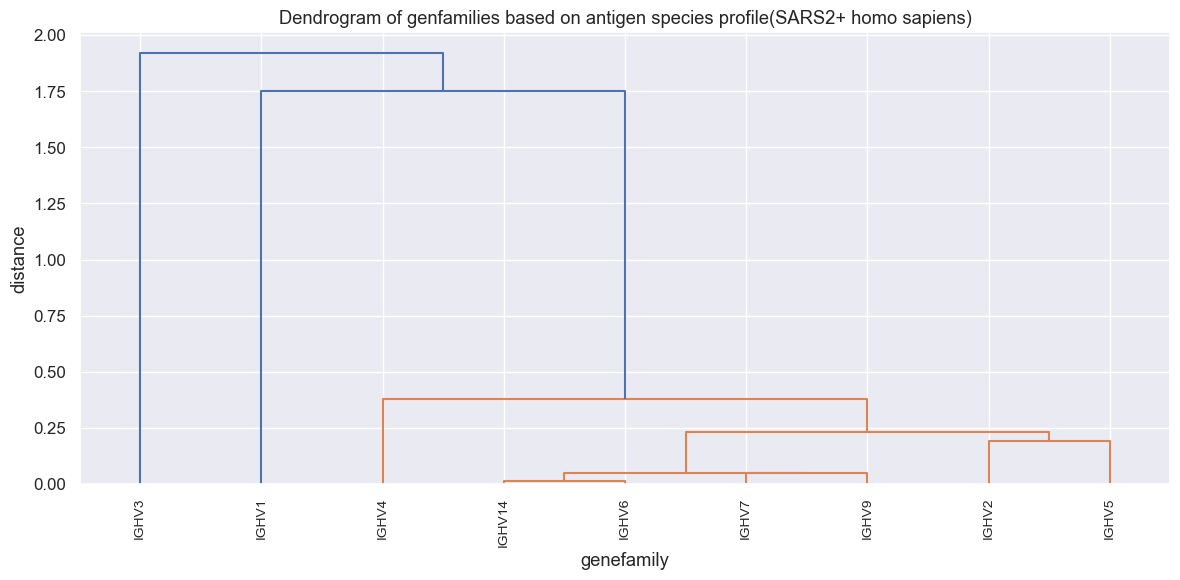

Cophenetische Korrelation der beiden Cluster: -0.057


In [65]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. CSV einlesen
# -------------------------------
df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

# -------------------------------
# 2. Spalte aufsplitten und explodieren
# -------------------------------
df["antigen_species"] = df["antigen_species"].str.split("|").apply(lambda x: [s.strip() for s in x])
df_exploded = df.explode("antigen_species")

# -------------------------------
# 3. Nur gewünschte Spezies behalten
# -------------------------------
relevant_species = ["severe acute respiratory syndrome coronavirus2", "homo sapiens"]
df_filtered = df_exploded[df_exploded["antigen_species"].isin(relevant_species)]

# -------------------------------
# 4. Pivot: Häufigkeit von species pro heavy_subclass
# -------------------------------
pivot = df_filtered.pivot_table(
    index="heavy_subclass",
    columns="antigen_species",
    aggfunc="size",
    fill_value=0
)

# -------------------------------
# 5. Standardisieren (Z-Scores) — optional
# -------------------------------
pivot_scaled = StandardScaler().fit_transform(pivot)

# -------------------------------
# 6. Hierarchisches Clustering (Ward)
# -------------------------------
linkage_matrix = linkage(pivot_scaled, method="single", metric="euclidean")

# -------------------------------
# 7. Dendrogramm plotten
# -------------------------------
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    labels=pivot.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None
)

plt.title("Dendrogram of genfamilies based on antigen species profile(SARS2+ homo sapiens)")
plt.xlabel("genefamily")
plt.ylabel("distance")
plt.tight_layout()
plt.show()



# --- 3. Cophenetische Distanzen für beide Cluster berechnen ---

coph_dist_1 = cophenet(Z, condensed_dist)[1]

pivot_dist = pdist(pivot_scaled, metric='euclidean')
coph_dist_2 = cophenet(linkage_matrix, pivot_dist)[1]

# --- 4. Cophenetische Korrelation zwischen beiden Clustern berechnen ---

correlation = np.corrcoef(coph_dist_1, coph_dist_2)[0, 1]

print(f"Cophenetische Korrelation der beiden Cluster: {correlation:.3f}")

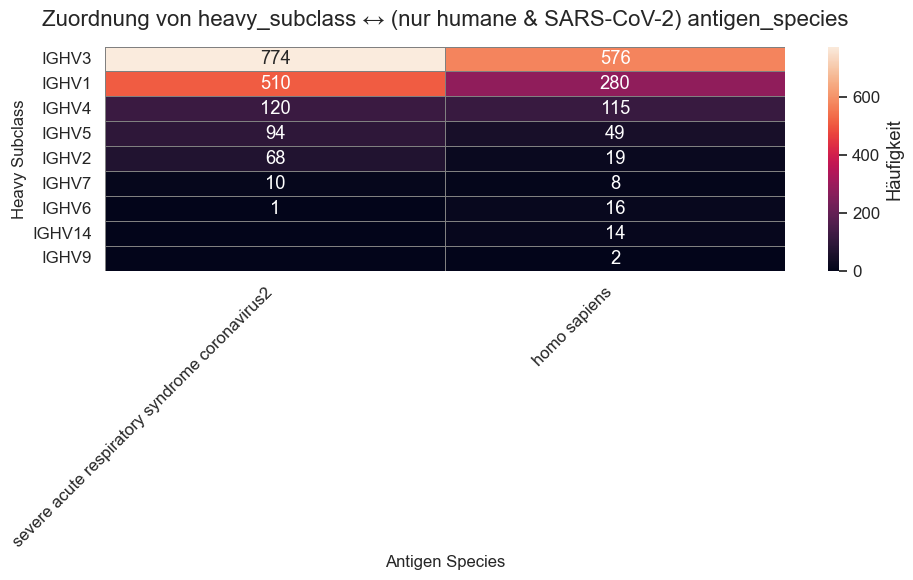

In [53]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1. CSV einlesen (Tabulator-getrennt)
# -------------------------------
df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

# -------------------------------
# 2. antigen_species aufsplitten & explodieren
# -------------------------------
df["antigen_species"] = df["antigen_species"].str.split("|").apply(lambda x: [s.strip() for s in x])
df_exploded = df.explode("antigen_species")

# -------------------------------
# 3. Nur gewünschte Spezies behalten
# -------------------------------
relevant_species = ["severe acute respiratory syndrome coronavirus2", "homo sapiens"]
df_filtered = df_exploded[df_exploded["antigen_species"].isin(relevant_species)]

# -------------------------------
# 4. Pivot-Tabelle erstellen (Zählung)
# -------------------------------
pivot = df_filtered.pivot_table(
    index="heavy_subclass",
    columns="antigen_species",
    aggfunc="size",
    fill_value=0
)

# -------------------------------
# 5. Achsen sortieren nach Häufigkeit
# -------------------------------
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
pivot = pivot[pivot.sum(axis=0).sort_values(ascending=False).index]

# -------------------------------
# 6. Werte für Annotation vorbereiten
# -------------------------------
annotations = pivot.copy()
annotations = annotations.where(annotations > 0, "")
annotations = annotations.astype(str)

# -------------------------------
# 7. Heatmap plotten
# -------------------------------
plt.figure(figsize=(10, 6))
sns.set(font_scale=1.1)
sns.heatmap(
    pivot,
    annot=annotations,
    fmt="s",
    cmap="rocket",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Häufigkeit"},
    square=False
)

plt.title("Zuordnung von heavy_subclass ↔ (nur humane & SARS-CoV-2) antigen_species", fontsize=16, pad=15)
plt.xlabel("Antigen Species", fontsize=12)
plt.ylabel("Heavy Subclass", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()